# import

In [1]:
import sys
sys.path.append('..')
import numpy as np
from collections import defaultdict
from StatTools.generators.ndfnoise_generator import ndfnoise
from StatTools.visualization import plot_ff
from StatTools.analysis.dfa import DFA, dfa, dfa_worker
from StatTools.analysis.utils import(
    analyse_zero_cross_ff,
    analyse_cross_ff_linregress,
    ff_params,
    var_estimation
) 
from scipy.stats import linregress
from synth import postprocess_collisions, gen_traj, draw_ants_with_direction, draw_traj
from joblib import Parallel, delayed, cpu_count
from tqdm import tqdm
import matplotlib.pyplot as plt
import pickle
import pandas as pd
import seaborn as sns
import plotly.express as px
from pathlib import Path

# dfa estimate real ants H

In [ ]:
def remove_intercept(x ,y):
    linreg = linregress(x, y)
    return y - linreg.intercept

def worker(series, n_integral, s_values):
        _, F2_s = dfa(dataset=series,
                    degree=2,
                    s_values=s_values,
                    processes=1,
                    n_integral=n_integral)
        F_s = np.sqrt(F2_s)
        return F_s, s_values

def plot_ff_slopes(
        hs: np.ndarray | None,
        S: np.ndarray,
        ff_parameter: ff_params,
        residuals: np.ndarray | None = None,
        ax=None,
        label:str = None,
        title:str = None,
        linestyle=None,
        color = None
        ):

    hurst = ff_parameter.slopes[0].value
    b = ff_parameter.intercept.value
    if hs is not None:
        hs_array = np.asarray(hs)
        S_new = np.repeat(S[:, np.newaxis], hs_array.shape[0], 1).T
        ax.scatter(S_new, hs_array)
    fit_func = 10 ** (hurst * np.log10(S) + b)
    ax.plot(S, fit_func, label=label, linestyle=linestyle, color=color)
    ax.set_xscale("log")
    ax.set_yscale("log")
    
    if title:
        ax.set_title(title)
    
    ax.grid(which='both', linewidth=0.5)
    return ax

# traj len analysis

In [ ]:
pyeensis_lens = []

pyeensis_dir  = Path(r'E:\asp\Ants\P.yeensis\knn_kalman')
pbar = tqdm(pyeensis_dir.glob("*.csv"), total=len(list(pyeensis_dir.glob("*.csv"))))
for path in pbar:
    
    df = pd.read_csv(path)
    trajs = df[['frame', 'track_id', 'x', 'y']].pivot(columns='track_id', index='frame', values=['x', 'y']).values.astype(np.float32)
    lens = (~np.isnan(trajs)).sum(axis=0)
    
    pyeensis_lens.extend(lens)

In [ ]:
frufa_lens = []

frufa_dir  = Path(r'E:\asp\Ants\F.rufa\knn_kalman')
pbar = tqdm(frufa_dir.glob("*.csv"), total=len(list(frufa_dir.glob("*.csv"))))
for path in pbar:
    
    df = pd.read_csv(path)
    trajs = df[['frame', 'track_id', 'x', 'y']].pivot(columns='track_id', index='frame', values=['x', 'y']).values.astype(np.float32)
    lens = (~np.isnan(trajs)).sum(axis=0)
    
    frufa_lens.extend(lens)

In [ ]:
with open('../data/artifacts/pyeensis_lens.pkl', 'wb') as f:
    pickle.dump(pyeensis_lens, f)

with open('../data/artifacts/frufa_lens.pkl', 'wb') as f:
    pickle.dump(frufa_lens, f)

In [ ]:
fig, ax = plt.subplots()
fig.set_size_inches((15, 7))

sns.histplot(frufa_lens, label='F.rufa', ax=ax, stat='density')
sns.histplot(pyeensis_lens, label='P.yeensis', ax=ax,  stat='density')
ax.legend()
ax.grid()
ax.set_yscale('log')

In [ ]:
pyeensis_dict = dict()

pyeensis_dir  = Path(r'E:\asp\Ants\P.yeensis\knn_kalman')
pbar = tqdm(pyeensis_dir.glob("*.csv"), total=len(list(pyeensis_dir.glob("*.csv"))))
for path in pbar:
    
    df = pd.read_csv(path)
    trajs = df[['frame', 'track_id', 'x', 'y']].pivot(columns='track_id', index='frame', values=['x', 'y']).values.astype(np.float32)

    # ind s_values for each random walk series
    tasks = []
    for j in range(trajs.shape[1]):
        series = trajs[:, j]
        series = series[~np.isnan(series)]

        if len(series)<48: continue

        s_values = np.array([int(np.exp(step)) for step in np.arange(np.log(6), np.log(len(series)/4), 0.4)])

        tasks.append([series, s_values])


    n_tasks = len(tasks)

    results = Parallel(n_jobs=4, backend='loky', verbose=0)(
        delayed(worker)(series, 0, s_values) for series, s_values in tqdm(tasks, desc=f'DFA calc', unit='series')
    )
    
    pyeensis_dict[path.name]=results
    
with open('../data/artifacts/pyeensis_ff_dict.pkl', 'wb') as f:
    pickle.dump(pyeensis_dict, f)

In [ ]:
frufa_dict = dict()

frufa_dir  = Path(r'E:\asp\Ants\F.rufa\knn_kalman')
pbar = tqdm(frufa_dir.glob("*.csv"), total=len(list(frufa_dir.glob("*.csv"))))
for path in pbar:
    
    df = pd.read_csv(path)
    trajs = df[['frame', 'track_id', 'x', 'y']].pivot(columns='track_id', index='frame', values=['x', 'y']).values.astype(np.float32)

    # ind s_values for each random walk series
    tasks = []
    for j in range(trajs.shape[1]):
        series = trajs[:, j]
        series = series[~np.isnan(series)]

        if len(series)<48: continue

        s_values = np.array([int(np.exp(step)) for step in np.arange(np.log(6), np.log(len(series)/4), 0.4)])

        tasks.append([series, s_values])


    n_tasks = len(tasks)

    results = Parallel(n_jobs=4, backend='loky', verbose=0)(
        delayed(worker)(series, 0, s_values) for series, s_values in tqdm(tasks, desc=f'DFA calc', unit='series')
    )
    
    frufa_dict[path.name]=results
    
with open('../data/artifacts/frufa_ff_dict.pkl', 'wb') as f:
    pickle.dump(frufa_dict, f)

# plot

In [84]:
frufa_ff_dict = pd.read_pickle('../data/artifacts/frufa_ff_dict.pkl')
pyeensis_ff_dict = pd.read_pickle('../data/artifacts/pyeensis_ff_dict.pkl')

In [85]:
pyeensis_long_df = []
for res in pyeensis_ff_dict.values():
    pyeensis_long_df.extend(res)
pyeensis_long_df = pd.DataFrame(pyeensis_long_df).explode([0, 1])
pyeensis_long_df.columns = ['F_s', 's_value']
pyeensis_long_df.F_s = pyeensis_long_df.F_s.astype(float)
pyeensis_long_df.s_value = pyeensis_long_df.s_value.astype(int)
pyeensis_long_df = pyeensis_long_df[pyeensis_long_df.F_s>1e-4]

In [86]:
frufa_long_df = []
for res in frufa_ff_dict.values():
    frufa_long_df.extend(res)
frufa_long_df = pd.DataFrame(frufa_long_df).explode([0, 1])
frufa_long_df.columns = ['F_s', 's_value']
frufa_long_df.F_s = frufa_long_df.F_s.astype(float)
frufa_long_df.s_value = frufa_long_df.s_value.astype(int)
frufa_long_df = frufa_long_df[frufa_long_df.F_s>1e-4]

In [87]:
linreg_pyeensis = linregress(np.log10(pyeensis_long_df.s_value), np.log10(pyeensis_long_df.F_s))
linreg_frufa = linregress(np.log10(frufa_long_df.s_value), np.log10(frufa_long_df.F_s))
frufa_s_values = frufa_long_df.s_value.unique()
pyeensis_s_values = pyeensis_long_df.s_value.unique()
frufa_line = 10**(linreg_frufa.slope * np.log10(frufa_s_values) + linreg_frufa.intercept)
pyeensis_line = 10**(linreg_pyeensis.slope * np.log10(pyeensis_s_values) + linreg_pyeensis.intercept) 

In [88]:
# fig, ax = plt.subplots()
# fig.set_size_inches((10, 10))
# sns.scatterplot(pyeensis_long_df, x='s_value', y='F_s', label='P.yeensis', marker='v', ax=ax, color='xkcd:grass green')
# sns.scatterplot(frufa_long_df, x='s_value', y='F_s', label='F.rufa', marker='s', ax=ax, color='xkcd:sky blue')
# ax.plot(pyeensis_s_values, pyeensis_line, label=f'H={linreg_pyeensis.slope:.2f}', color='xkcd:grass green')
# ax.plot(frufa_s_values, frufa_line, label=f'H={linreg_frufa.slope:.2f}', color='xkcd:sky blue')
# ax.set_xscale('log')
# ax.set_yscale('log')
# ax.grid()
# ax.legend()

In [89]:
pyeensis_long_df_agg = pyeensis_long_df.groupby('s_value').agg(['median', 'mean'])
pyeensis_long_df_agg = pyeensis_long_df_agg.droplevel(level=0, axis=1).reset_index()

frufa_long_df_agg = frufa_long_df.groupby('s_value').agg(['median', 'mean'])
frufa_long_df_agg = frufa_long_df_agg.droplevel(level=0, axis=1).reset_index()

In [90]:
pyeensis_ff_params, _ = analyse_cross_ff_linregress(pyeensis_long_df_agg['median'].values, pyeensis_long_df_agg['s_value'].values)
frufa_ff_params, _ = analyse_zero_cross_ff(frufa_long_df_agg['median'].values, frufa_long_df_agg['s_value'].values)

In [106]:
pyeensis_cross = pyeensis_ff_params.cross[0].value
linreg_pyeensis_1 = linregress(np.log10(pyeensis_long_df_agg.loc[pyeensis_long_df_agg.s_value<pyeensis_cross, 's_value']), np.log10(pyeensis_long_df_agg.loc[pyeensis_long_df_agg.s_value<pyeensis_cross, 'median']))
pyeensis_line_1 = 10**(linreg_pyeensis_1.slope * np.log10(pyeensis_s_values) + linreg_pyeensis_1.intercept)

linreg_pyeensis_2 = linregress(np.log10(pyeensis_long_df_agg.loc[pyeensis_long_df_agg.s_value>=pyeensis_cross, 's_value']), np.log10(pyeensis_long_df_agg.loc[pyeensis_long_df_agg.s_value>=pyeensis_cross, 'median']))
pyeensis_line_2 = 10**(linreg_pyeensis_2.slope * np.log10(pyeensis_s_values) + linreg_pyeensis_2.intercept) 

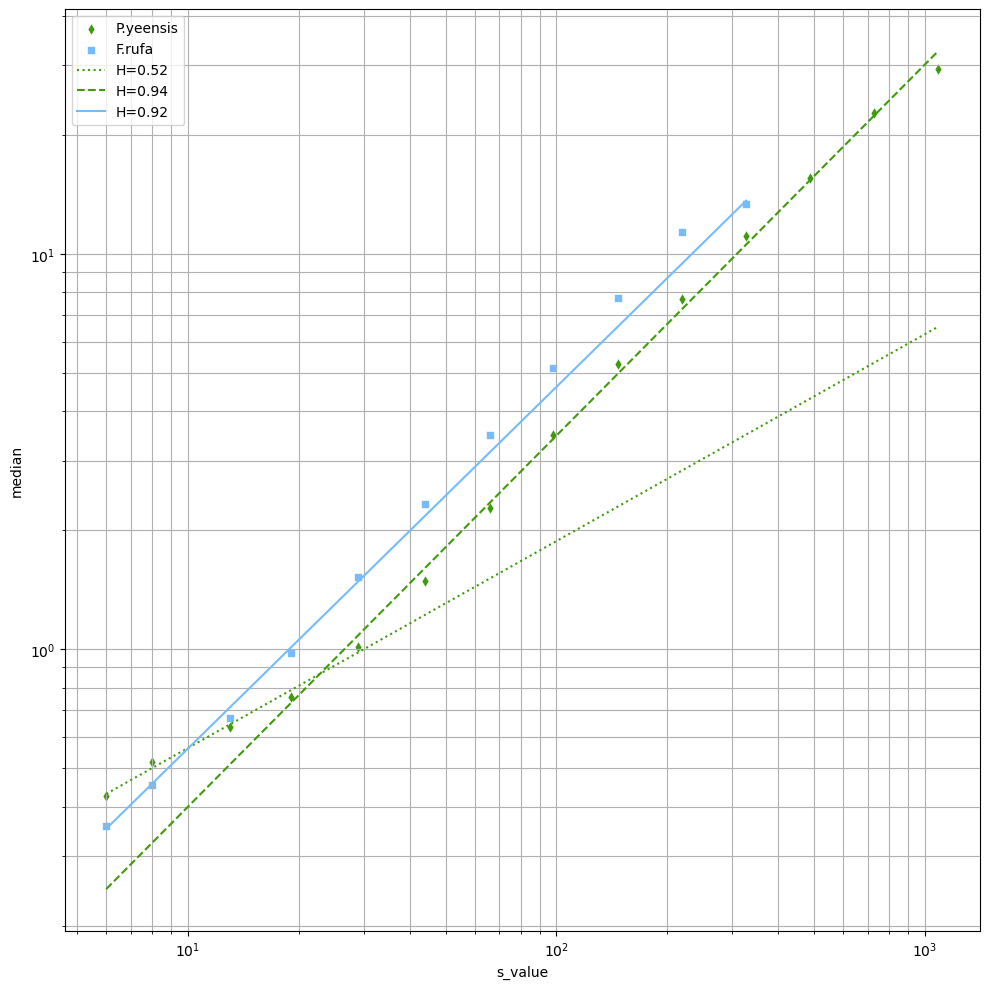

In [117]:
fig, ax = plt.subplots()
fig.set_size_inches((10, 10))

sns.scatterplot(pyeensis_long_df_agg, x='s_value', y='median', label='P.yeensis', marker='d', ax=ax, color='xkcd:grass green')
sns.scatterplot(frufa_long_df_agg, x='s_value', y='median', label='F.rufa', marker='s', ax=ax, color='xkcd:sky blue')
ax.plot(pyeensis_s_values, pyeensis_line_1, label=f'H={linreg_pyeensis_1.slope:.2f}', color='xkcd:grass green', linestyle=':')
ax.plot(pyeensis_s_values, pyeensis_line_2, label=f'H={linreg_pyeensis_2.slope:.2f}', color='xkcd:grass green', linestyle='--')
ax.plot(frufa_s_values, frufa_line, label=f'H={linreg_frufa.slope:.2f}', color='xkcd:sky blue')
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(which='both')
ax.legend()

plt.tight_layout()
plt.show()

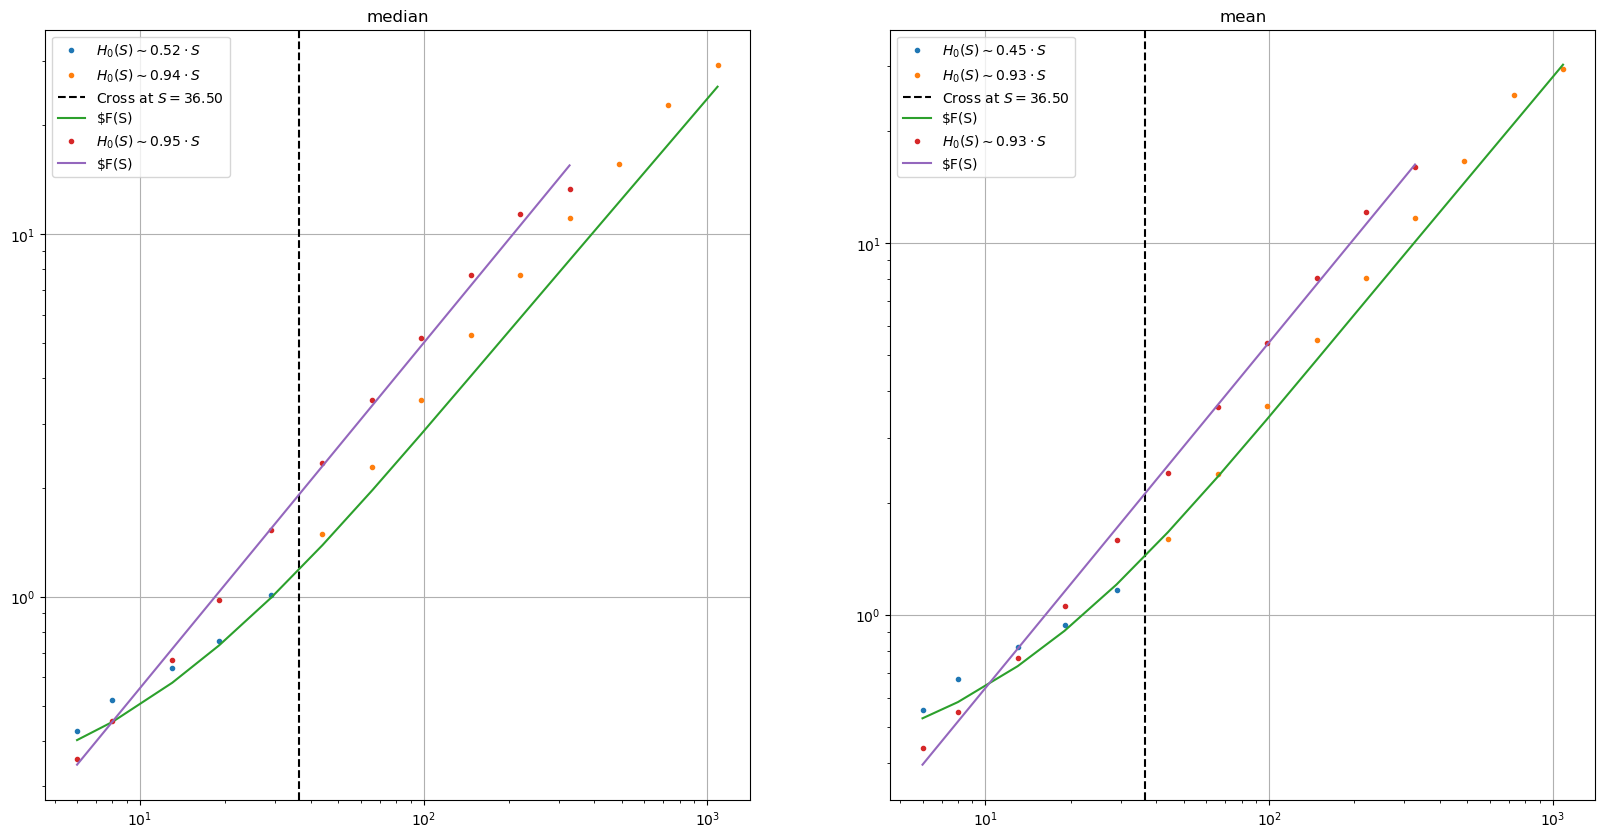

In [93]:
pyeensis_ff_params_median, _ = analyse_cross_ff_linregress(pyeensis_long_df_agg['median'].values, pyeensis_long_df_agg['s_value'].values)
frufa_ff_params_median, _ = analyse_zero_cross_ff(frufa_long_df_agg['median'].values, frufa_long_df_agg['s_value'].values)
fig, ax = plt.subplots(ncols=2)
fig.set_size_inches((20, 10))
plot_ff(
    pyeensis_long_df_agg['median'].values,
    pyeensis_long_df_agg['s_value'].values,
    ff_parameter=pyeensis_ff_params_median,
    residuals=None,
    ax=ax[0],
    title='median'
)
plot_ff(
    frufa_long_df_agg['median'].values,
    frufa_long_df_agg['s_value'].values,
    ff_parameter=frufa_ff_params_median,
    residuals=None,
    ax=ax[0],
    # title=f'Level {level}'
)

pyeensis_ff_params_mean, _ = analyse_cross_ff_linregress(pyeensis_long_df_agg['mean'].values, pyeensis_long_df_agg['s_value'].values)
frufa_ff_params_mean, _ = analyse_zero_cross_ff(frufa_long_df_agg['mean'].values, frufa_long_df_agg['s_value'].values)

plot_ff(
    pyeensis_long_df_agg['mean'].values,
    pyeensis_long_df_agg['s_value'].values,
    ff_parameter=pyeensis_ff_params_mean,
    residuals=None,
    ax=ax[1],
    title='mean'
)
plot_ff(
    frufa_long_df_agg['mean'].values,
    frufa_long_df_agg['s_value'].values,
    ff_parameter=frufa_ff_params_mean,
    residuals=None,
    ax=ax[1],
    # title=f'Level {level}'
)
ax[1].grid()
ax[0].grid()